# Day 4 · NumPy 实战:模拟数据 + 统计(3/3)

目标:用 np.random 生成模拟数据,算统计量,画简单的图——把前三天学的 NumPy 用起来。

今日节奏:40min 学习 + 15min 动手 + 5min 自检(最后有清单)。

> 打开方式:JupyterLab(http://127.0.0.1:8888/lab)文件树里进 `ai-learning/练习/` 双击本文件,逐格 Shift+Enter。


In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python", sys.version.split()[0], "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)
print("环境 OK!开始今天的练习 →")


Python 3.14.6 | numpy 2.5.2 | matplotlib 3.11.1
环境 OK!开始今天的练习 →


## 任务 1:可复现的随机数(seed)

随机数不是"乱":给同一个 **seed(种子)**,生成的序列就完全一样。这样你的实验别人能复现,debug 时也不会一会儿一个结果。

- `np.random.default_rng(42)` → 新版推荐 API,得到一个独立的随机数生成器
- `rng.normal(0, 1, 5)` → 5 个标准正态分布(均值 0、标准差 1)的随机数
- `rng.integers(0, 10, 5)` → 5 个 0~9 的整数

先猜:用同一个 seed 建两个 rng,出来的数字一样吗?


In [5]:
rng1 = np.random.default_rng(42)
rng2 = np.random.default_rng(42)

a = rng1.normal(0, 1, 5)
b = rng2.normal(0, 1, 5)
print("第一次:", np.round(a, 3))
print("第二次:", np.round(b, 3))
print("完全一样?", np.array_equal(a, b))

rng3 = np.random.default_rng(7)   # 换个 seed
print("换 seed:", np.round(rng3.normal(0, 1, 5), 3))


第一次: [ 0.305 -1.04   0.75   0.941 -1.951]
第二次: [ 0.305 -1.04   0.75   0.941 -1.951]
完全一样? True
换 seed: [ 0.001  0.299 -0.274 -0.891 -0.455]


## 任务 2:生成模拟数据 + 常用统计量

模拟 200 名学生的期末成绩:均值 75、标准差 10 的正态分布,再裁剪到 0~100(分数没有负的)。

常用统计量(都是 NumPy 函数):
- `mean` 均值(平均水平)、`median` 中位数(抗极端值)、`std` 标准差(离散程度)
- `min` / `max` 最值、`percentile` 分位数(比如 90% 的人在多少分以下)

先猜:正态分布下 mean 和 median 谁大?


In [3]:
rng = np.random.default_rng(2026)
scores = rng.normal(75, 10, 200)        # 200 个 ~ N(75, 10)
scores = np.clip(scores, 0, 100)        # 裁剪到合法区间

print("样本数:", scores.size)
print("mean:", round(scores.mean(), 2))
print("median:", np.median(scores))
print("std:", round(scores.std(), 2))
print("min/max:", scores.min(), scores.max())
print("25% / 50% / 75% 分位:", np.percentile(scores, [25, 50, 75]).round(2))
print("90% 的人在多少分以下:", np.percentile(scores, 90).round(2))


样本数: 200
mean: 75.67
median: 76.1481157149644
std: 10.76
min/max: 37.525861418691065 100.0
25% / 50% / 75% 分位: [68.14 76.15 82.68]
90% 的人在多少分以下: 88.99


## 任务 3:两组对比(复习 axis)

模拟对照组和实验组各 150 人,均值分别是 70 和 76:
- 用 `np.vstack` 把两组拼成 (2, 150) 的矩阵
- 用 `axis=1` 一次算出两组的 mean / std

先猜:axis=1 算出来的结果长度是几?


In [6]:
rng = np.random.default_rng(1)
control = rng.normal(70, 12, 150)
treated = rng.normal(76, 12, 150)

groups = np.vstack([control, treated])   # 形状 (2, 150)
print("形状:", groups.shape)
print("两组均值(axis=1):", groups.mean(axis=1).round(2))
print("两组标准差(axis=1):", groups.std(axis=1).round(2))
print("差值:", (groups.mean(axis=1)[1] - groups.mean(axis=1)[0]).round(2))


形状: (2, 150)
两组均值(axis=1): [69.02 74.51]
两组标准差(axis=1): [10.53 11.56]
差值: 5.49


## 任务 4:相关性和"特征 → 目标"思维

学习时长(小时)和成绩之间通常有正相关。构造:学习时长 2~8 小时均匀随机,成绩 = 50 + 6×时长 + 噪声。

`np.corrcoef(hours, scores)` 返回 2×2 相关矩阵,取值 -1~1:
- 接近 1:正相关(时长越长分越高)
- 接近 -1:负相关
- 接近 0:线性关系弱

这个"两列数据之间关系"的视角,就是以后机器学习里 **特征(feature)和目标(target)** 的雏形。


In [8]:
rng = np.random.default_rng(99)
hours = rng.uniform(2, 8, 100)              # 100 个 2~8 的均匀随机数
noise = rng.normal(0, 6, 100)
final = 50 + 6 * hours + noise              # 线性关系 + 噪声

corr = np.corrcoef(hours, final)[0, 1]
print("相关系数:", round(corr, 3))
print("学习最多的人用时(小时):", hours.max().round(2), "| 分数:", final[hours.argmax()].round(1))


第一次: 0.853
相关系数: 0.853
学习最多的人用时(小时): 7.96 | 分数: 90.9


## 任务 5:简单可视化

两张图就够了:
- 直方图 `plt.hist`:看**一个变量**的分布
- 散点图 `plt.scatter`:看**两个变量**的关系

说明:图内文字先用英文,避免这台机器中文字体的坑;print 里中文按老规矩用 UTF-8。


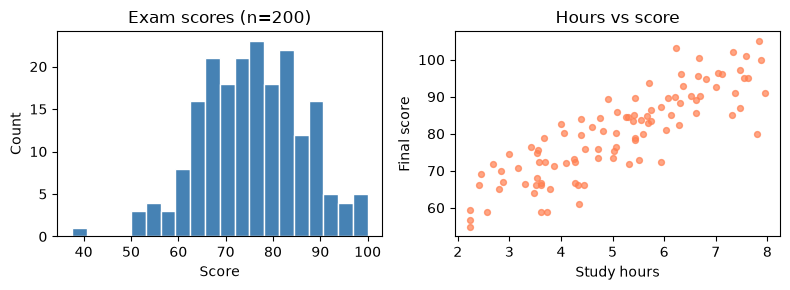

In [9]:
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(scores, bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Exam scores (n=200)")

plt.subplot(1, 2, 2)
plt.scatter(hours, final, s=18, alpha=0.7, color="coral")
plt.xlabel("Study hours")
plt.ylabel("Final score")
plt.title("Hours vs score")

plt.tight_layout()
plt.show()


## 任务 6:小挑战 🔥(标准化的雏形)

给 `scores` 做标准化:`z = (x - mean) / std`。

要求:
1. 算出标准化后的数组 `z`
2. 打印 `z.mean()` 和 `z.std()`(应该接近 0 和 1)
3. 用布尔掩码找出原始成绩低于 60 分的人,打印人数和占比

为什么学这个?以后很多模型(线性回归、神经网络)都假设输入**均值 0、方差 1**,这个操作叫 standardization。


In [10]:
z = (scores - scores.mean()) / scores.std()
print("z.mean:", round(z.mean(), 10))
print("z.std:", round(z.std(), 10))

failed = scores[scores < 60]
print("不及格人数:", failed.size)
print("占比:", round(failed.size / scores.size * 100, 1), "%")


z.mean: 0.0
z.std: 1.0
不及格人数: 11
占比: 5.5 %


## 自检清单(6 问,答不上就回看今天的格子)

1. 为什么固定 seed? → 同样 seed 得到同样的随机序列,实验可复现、好调试
2. `np.random.default_rng` 和旧接口 `np.random.rand`? → default_rng 是新推荐 API,自带独立状态,不污染全局;旧接口也能用
3. mean / median / std / percentile 分别回答什么问题? → 平均水平 / 抗异常值的中心 / 离散程度 / 某个比例的人低于多少
4. 相关系数取值? → -1~1;正负号看方向,绝对值看强度,接近 0 表示线性关系弱
5. 直方图和散点图? → 直方图看单变量分布;散点图看两变量关系
6. 标准化公式 `(x - mean) / std` 后有什么特征? → 均值约 0、标准差约 1

## 📝 收盘动作

```powershell
cd D:\01_Study\ai-learning
git add -A; git commit -m "day4: numpy stats"; git push
```

然后跟助手说"生成日志"。
